# Training ResNet for Audio Spoofing Detection

ResNet model adapted from **Deep Residual Neural Networks for Audio Spoofing Detection** ([paper](https://dx.doi.org/10.21437/Interspeech.2019-3174), [repo](https://github.com/nesl/asvspoof2019/tree/master)). <br>
Training procedure adapted from **Towards Frequency Band Explainability in Synthetic Speech Detection** ([paper](https://dx.doi.org/10.23919/EUSIPCO58844.2023.10289804))

In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [2]:
import random
import numpy as np
import torch
import os

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

SEED = 42
set_seed(SEED)

In [4]:
from src.data_utils import ASVDataset, collate_fn_asvspoof
from src.features import log_spectrum_extractor, band_isolator
from src.samplers import BalancedBatchSampler
from src.utils import EarlyStopping
from src.models.resnet import SpectrogramModel
from sklearn.metrics import roc_curve, roc_auc_score, balanced_accuracy_score
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

from IPython.display import Audio, display
from torchinfo import summary
from tqdm.auto import tqdm

import soundfile as sf
import librosa
import pandas as pd
import matplotlib.pyplot as plt

## Loading LA subset + extracting features
- All audio clips are resized to a length of 2 seconds (32,000 samples);
- Log-spectrograms are computed for every audio clip (window size = 2048 with 25% overlap)

In [5]:
DATA_PATH = str(Path.cwd().parent / 'data' / 'ASVspoof2019_LA')
PROTOCOLS_PATH = str(Path.cwd().parent / 'data' / 'ASVspoof2019_LA' / 'ASVspoof2019_LA_cm_protocols')
CACHE_DIR = str(Path.cwd().parent / 'data_caches')

band_transform = band_isolator(num_bands=5, isolated_band=4)

FEATURE_NAME = 'spec'

In [6]:
train_data = ASVDataset(
    database_path=DATA_PATH, protocols_path=PROTOCOLS_PATH, 
    is_train=True, feature_name=FEATURE_NAME, cache_dir=CACHE_DIR,
    max_duration=3.0, pad_to_max=True, use_vad=True, transform=log_spectrum_extractor, online_transform=band_transform
)

sysid_dict_inv {0: '-', 1: 'A01', 2: 'A02', 3: 'A03', 4: 'A04', 5: 'A05', 6: 'A06'}
data_root /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
dset_name train
protocols_fname train.trn
protocols_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
files_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_train/flac
protocols_file /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt
cache_fname /root/reproduction-salvi-et-al/data_caches/cache_train_LA_spec_3.0s_pad_vad.npy
Loading dataset from cache: /root/reproduction-salvi-et-al/data_caches/cache_train_LA_spec_3.0s_pad_vad.npy
Dataset loaded from cache successfully


In [7]:
dev_data = ASVDataset(
    database_path=DATA_PATH, protocols_path=PROTOCOLS_PATH, 
    is_train=False, feature_name=FEATURE_NAME, cache_dir=CACHE_DIR,
    max_duration=3.0, pad_to_max=True, use_vad=True, transform=log_spectrum_extractor, online_transform=band_transform
)

sysid_dict_inv {0: '-', 1: 'A01', 2: 'A02', 3: 'A03', 4: 'A04', 5: 'A05', 6: 'A06'}
data_root /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
dset_name dev
protocols_fname dev.trl
protocols_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
files_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_dev/flac
protocols_file /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt
cache_fname /root/reproduction-salvi-et-al/data_caches/cache_dev_LA_spec_3.0s_pad_vad.npy
Loading dataset from cache: /root/reproduction-salvi-et-al/data_caches/cache_dev_LA_spec_3.0s_pad_vad.npy
Dataset loaded from cache successfully


In [8]:
eval_data = ASVDataset(
    database_path=DATA_PATH, protocols_path=PROTOCOLS_PATH,
    is_eval=True, feature_name=FEATURE_NAME, cache_dir=CACHE_DIR,
    max_duration=3.0, pad_to_max=True, use_vad=True, transform=log_spectrum_extractor, online_transform=band_transform
)

sysid_dict_inv {0: '-', 1: 'A07', 2: 'A08', 3: 'A09', 4: 'A10', 5: 'A11', 6: 'A12', 7: 'A13', 8: 'A14', 9: 'A15', 10: 'A16', 11: 'A17', 12: 'A18', 13: 'A19'}
data_root /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
dset_name eval
protocols_fname eval.trl
protocols_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
files_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_eval/flac
protocols_file /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt
cache_fname /root/reproduction-salvi-et-al/data_caches/cache_eval_LA_spec_3.0s_pad_vad.npy
Loading dataset from cache: /root/reproduction-salvi-et-al/data_caches/cache_eval_LA_spec_3.0s_pad_vad.npy
Dataset loaded from cache successfully


In [9]:
def read_demo_file(path, max_duration):
    audio, sample_rate = sf.read(path, dtype='float32')
    max_samples = int(max_duration * sample_rate)

    from src.vad import trim_silence
    from src.data_utils import pad
    audio = trim_silence(audio)
            
    audio = pad(audio, max_samples, pad_to_max=True)
                
    return audio

In [10]:
demo_indices = [0, 3000, 3000 + 3800 * 2, 3000 + 3800 * 4]
demos = []

for idx, sample_idx in enumerate(demo_indices):
    D, label, meta = train_data[sample_idx]
    audio = read_demo_file(meta.path, 3.0)
    demos.append((audio, D.numpy()[0], label, meta))

In [11]:
for audio, _, label, meta in demos:
    print(f"\n{'Bonafide' if label == 1.0 else 'Spoof'} - {meta.file_name}")
    print(f"System: {train_data.sysid_dict_inv[meta.sys_id]}")
    display(Audio(audio, rate=16000))


Bonafide - LA_T_1138215
System: -



Spoof - LA_T_3740126
System: A01



Spoof - LA_T_3711779
System: A03



Spoof - LA_T_3285771
System: A05


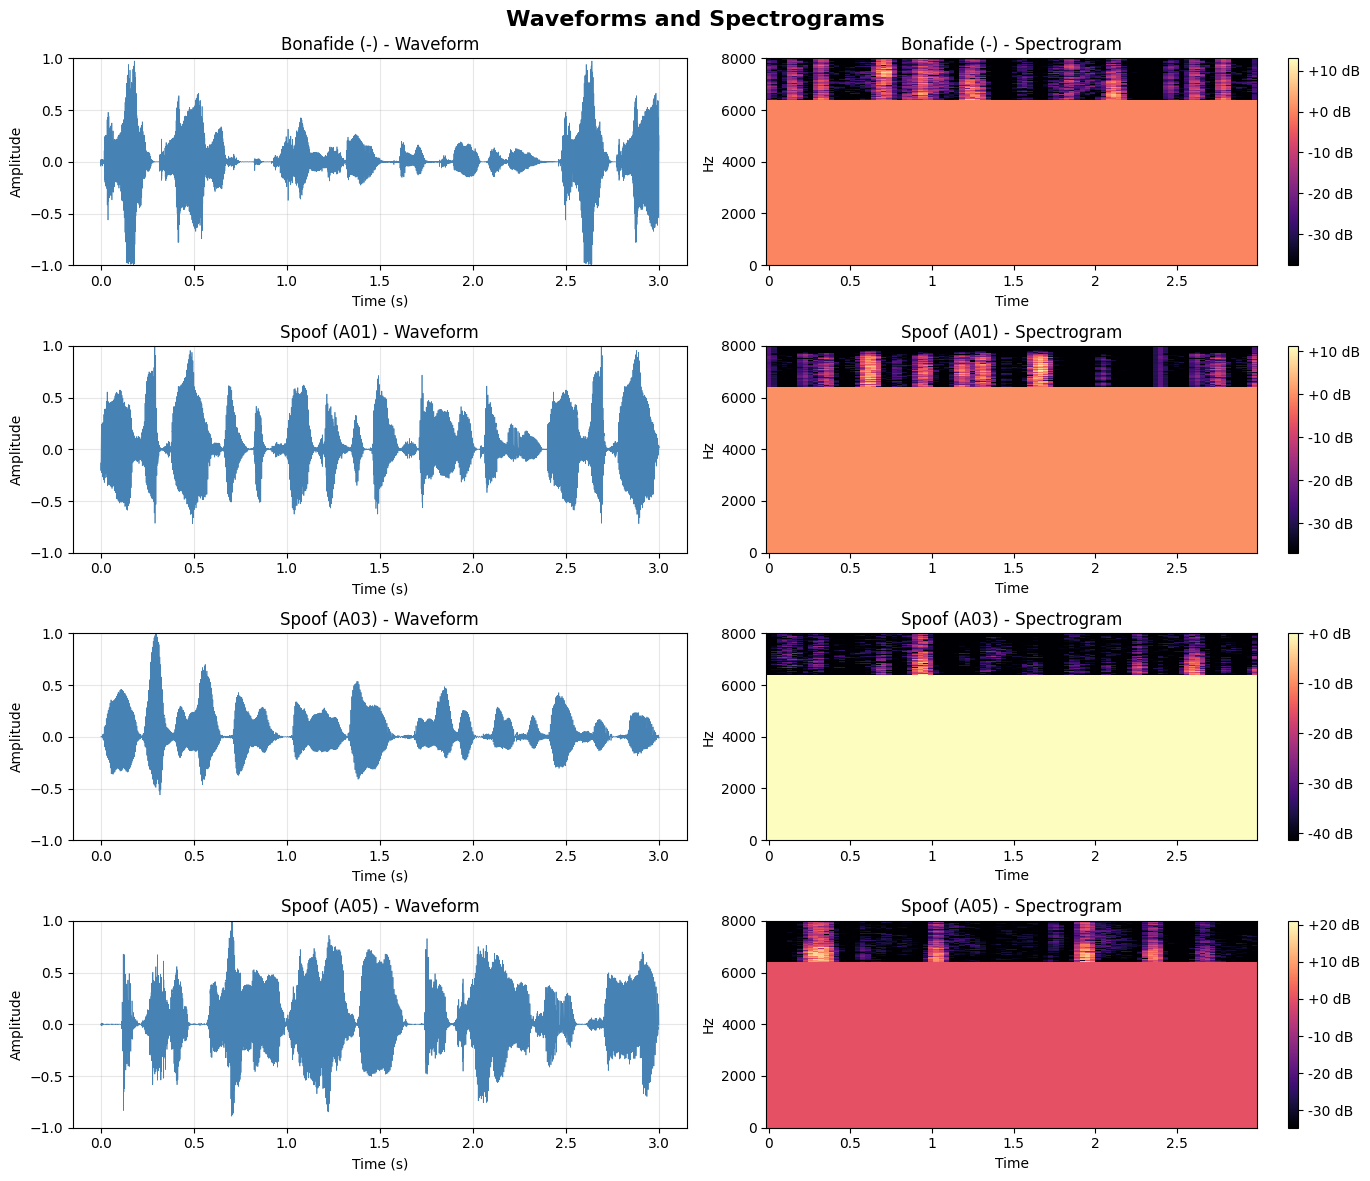

In [12]:
fig, axes = plt.subplots(len(demo_indices), 2, figsize=(14, 3*len(demo_indices)))

for idx, (audio, D, label, meta) in enumerate(demos):
    sys_name = train_data.sysid_dict_inv[meta.sys_id]
    label_name = 'Bonafide' if label == 1.0 else 'Spoof'
    
    # Waveform
    ax_wave = axes[idx, 0]
    time = np.arange(len(audio)) / 16000
    ax_wave.plot(time, audio, linewidth=0.5, color='steelblue')
    ax_wave.set_title(f'{label_name} ({sys_name}) - Waveform')
    ax_wave.set_xlabel('Time (s)')
    ax_wave.set_ylabel('Amplitude')
    ax_wave.set_ylim(-1, 1)
    ax_wave.grid(alpha=0.3)
    
    # Spectrogram
    ax_spec = axes[idx, 1]
    img = librosa.display.specshow(D, sr=16000, x_axis='time', y_axis='hz', 
                                    ax=ax_spec, cmap='magma')
    ax_spec.set_title(f'{label_name} ({sys_name}) - Spectrogram')
    plt.colorbar(img, ax=ax_spec, format='%+2.0f dB')

fig.suptitle('Waveforms and Spectrograms', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
demo_indices = [0, 3000, 3000 + 3800 * 2, 3000 + 3800 * 4]
demos = []

for idx, sample_idx in enumerate(demo_indices):
    D, label, meta = dev_data[sample_idx]
    audio = read_demo_file(meta.path, 3.0)
    demos.append((audio, D.numpy()[0], label, meta))

In [14]:
for audio, _, label, meta in demos:
    print(f"\n{'Bonafide' if label == 1.0 else 'Spoof'} - {meta.file_name}")
    print(f"System: {dev_data.sysid_dict_inv[meta.sys_id]}")
    display(Audio(audio, rate=16000))


Bonafide - LA_D_1047731
System: -



Spoof - LA_D_1862819
System: A01



Spoof - LA_D_7193153
System: A03



Spoof - LA_D_3100634
System: A05


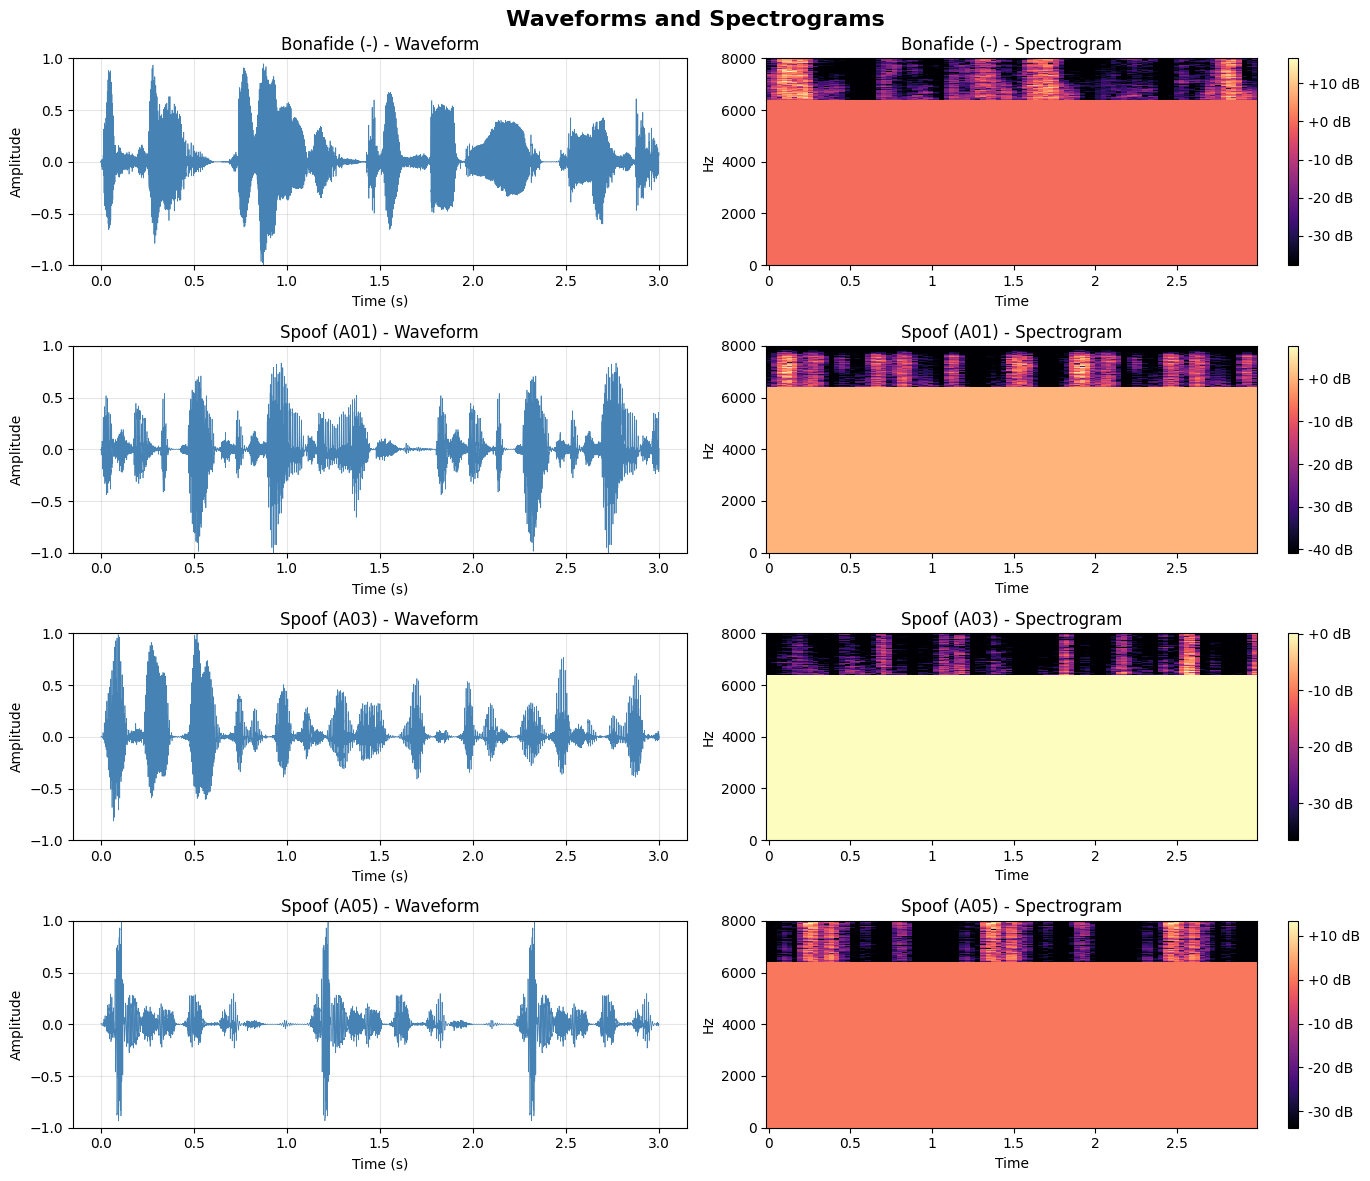

In [15]:
fig, axes = plt.subplots(len(demo_indices), 2, figsize=(14, 3*len(demo_indices)))

for idx, (audio, D, label, meta) in enumerate(demos):
    sys_name = dev_data.sysid_dict_inv[meta.sys_id]
    label_name = 'Bonafide' if label == 1.0 else 'Spoof'
    
    # Waveform
    ax_wave = axes[idx, 0]
    time = np.arange(len(audio)) / 16000
    ax_wave.plot(time, audio, linewidth=0.5, color='steelblue')
    ax_wave.set_title(f'{label_name} ({sys_name}) - Waveform')
    ax_wave.set_xlabel('Time (s)')
    ax_wave.set_ylabel('Amplitude')
    ax_wave.set_ylim(-1, 1)
    ax_wave.grid(alpha=0.3)
    
    # Spectrogram
    ax_spec = axes[idx, 1]
    img = librosa.display.specshow(D, sr=16000, x_axis='time', y_axis='hz', 
                                    ax=ax_spec, cmap='magma')
    ax_spec.set_title(f'{label_name} ({sys_name}) - Spectrogram')
    plt.colorbar(img, ax=ax_spec, format='%+2.0f dB')

fig.suptitle('Waveforms and Spectrograms', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
demo_indices = [0, 3000, 3000 + 3800 * 2, 3000 + 3800 * 4]
demos = []

for idx, sample_idx in enumerate(demo_indices):
    D, label, meta = eval_data[sample_idx]
    audio = read_demo_file(meta.path, 3.0)
    demos.append((audio, D.numpy()[0], label, meta))

In [17]:
for audio, _, label, meta in demos:
    print(f"\n{'Bonafide' if label == 1.0 else 'Spoof'} - {meta.file_name}")
    print(f"System: {eval_data.sysid_dict_inv[meta.sys_id]}")
    display(Audio(audio, rate=16000))


Spoof - LA_E_2834763
System: A11



Spoof - LA_E_5522956
System: A16



Spoof - LA_E_2840419
System: A12



Spoof - LA_E_5934868
System: A14


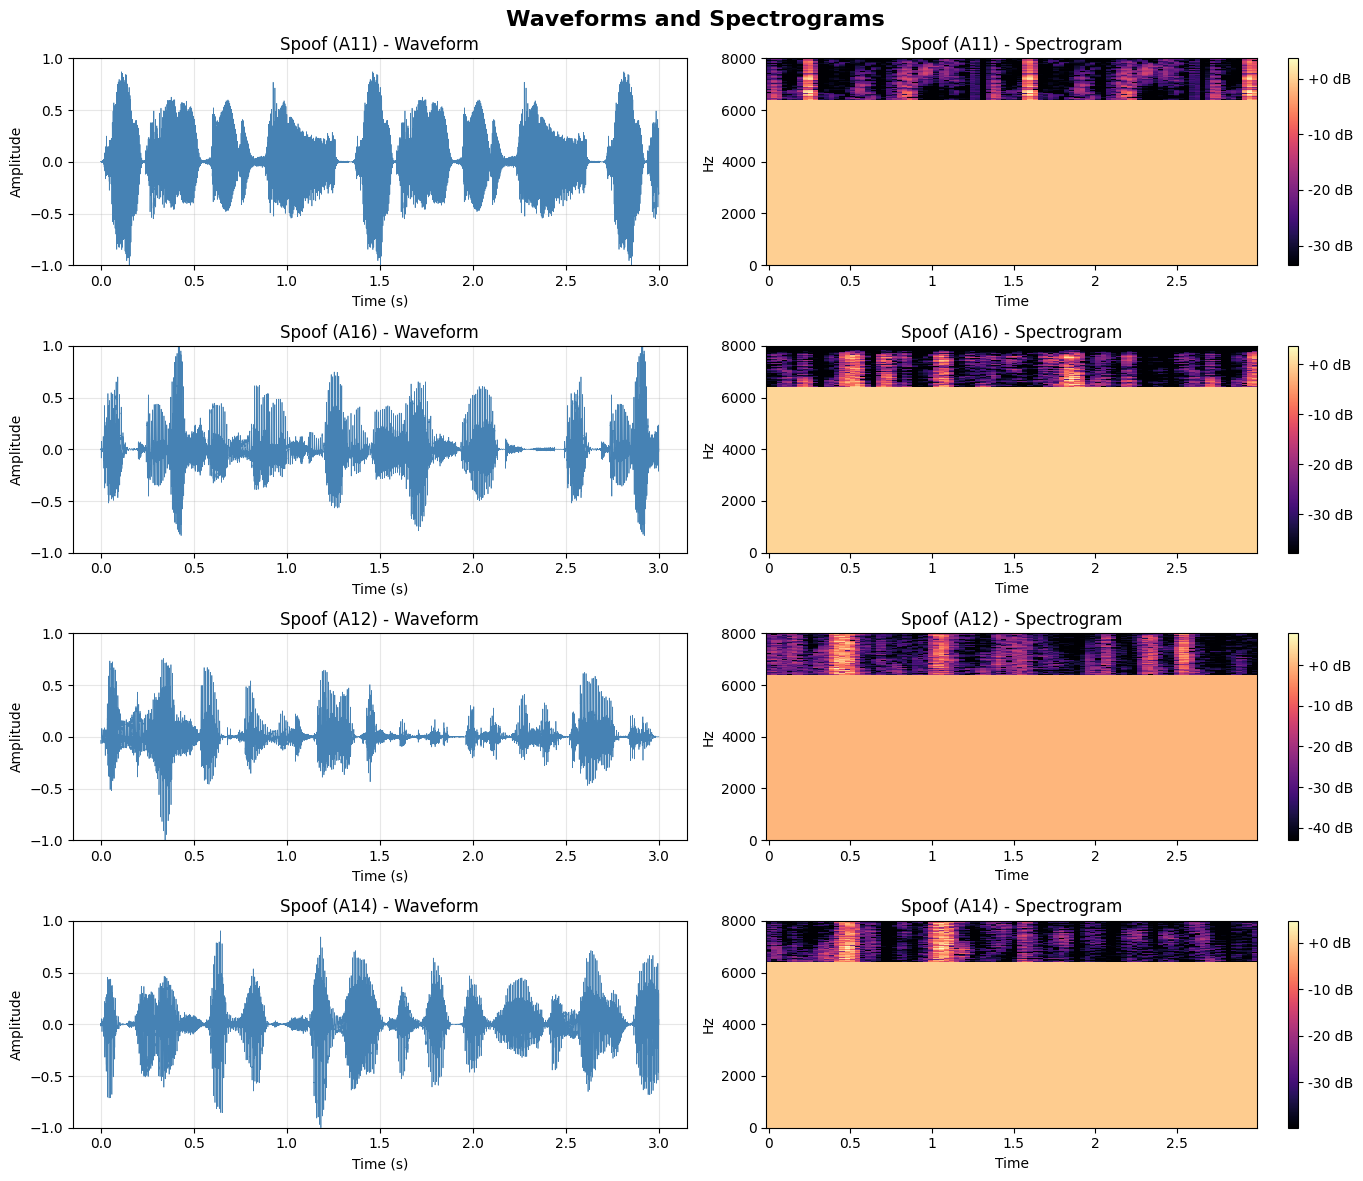

In [18]:
fig, axes = plt.subplots(len(demo_indices), 2, figsize=(14, 3*len(demo_indices)))

for idx, (audio, D, label, meta) in enumerate(demos):
    sys_name = eval_data.sysid_dict_inv[meta.sys_id]
    label_name = 'Bonafide' if label == 1.0 else 'Spoof'
    
    # Waveform
    ax_wave = axes[idx, 0]
    time = np.arange(len(audio)) / 16000
    ax_wave.plot(time, audio, linewidth=0.5, color='steelblue')
    ax_wave.set_title(f'{label_name} ({sys_name}) - Waveform')
    ax_wave.set_xlabel('Time (s)')
    ax_wave.set_ylabel('Amplitude')
    ax_wave.set_ylim(-1, 1)
    ax_wave.grid(alpha=0.3)
    
    # Spectrogram
    ax_spec = axes[idx, 1]
    img = librosa.display.specshow(D, sr=16000, x_axis='time', y_axis='hz', 
                                    ax=ax_spec, cmap='magma')
    ax_spec.set_title(f'{label_name} ({sys_name}) - Spectrogram')
    plt.colorbar(img, ax=ax_spec, format='%+2.0f dB')

fig.suptitle('Waveforms and Spectrograms', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()